NEDO Quantum Challenge Season2 - IBM Seminar #1

# Qiskit 入門ハンズオン

Kifumi Numata, IBM Quantum (Oct 07, 2026)

コードセルは、セルを選択して「Shift」＋「Enter」、または上部の三角アイコンをクリックすると実行できます。

In [ ]:
# Qiskitバージョンの確認
import qiskit
qiskit.__version__

## 目次
1. 量子回路    
   1.1 すべての情報はビットである    
   1.2 回路図を使った計算    
2. 単一量子ビット回路    
   2.1 量子状態とブロッホ球    
   2.2 その他の1量子ビットゲート       
   演習1. 単一量子ビット回路    
   2.3 測定    
3. 複数量子ビット回路ともつれ状態    
   3.1 複数量子ビット回路    
   3.2 複数量子ゲート    
   3.3 量子もつれと実デバイスでの実行    
   演習2. 量子もつれと実デバイスでの実行       
   3.4 GHZ状態     
   演習3. 8量子ビットのGHZ状態    

# 1. 量子回路

## 1.1 すべての情報はビットである

すべての情報はコンピューター上で `0`と`1`のビットで表現され、演算されます。

例えば 9213 という数は10進数表現されています。

$$ (9\times10^3) + (2\times10^2) + (1\times10^1) + (3\times10^0) $$

これを二進数表現すると、10001111111101 になります。
$$
\begin{aligned}
9213  &= (1 \times 2^{13}) + (0 \times 2^{12}) + (0 \times 2^{11}) + (0 \times 2^{10}) \\
 &+ (1 \times 2^9) + (1 \times 2^8) + (1 \times 2^7) + (1 \times 2^6) \\
 &+ (1 \times 2^5) + (1 \times 2^4) + (1 \times 2^3) + (1 \times 2^2) \\
 &+ (0 \times 2^1) + (1 \times 2^0) 
\end{aligned}
$$

量子コンピューターも同じように情報をビットで表現して、演算を行います。ただし、量子ビットを用います。

## 1.2 回路図を使った計算

量子ビットを使用する場合もビットを使用する場合も、入力を必要な出力に変換するためにそれらを操作する必要があります。少数のビット用の非常に単純なプログラムでは、このプロセスを **回路図** と呼ばれる図で表すと便利です。    
左下の図が古典回路の例、右下の図が量子回路の例です。
どちらの場合も、左側に入力があり、出力が右側で、その間に演算が記号によって表されます。演算に用いられる記号は、主に歴史的な背景から「ゲート」と呼ばれます。

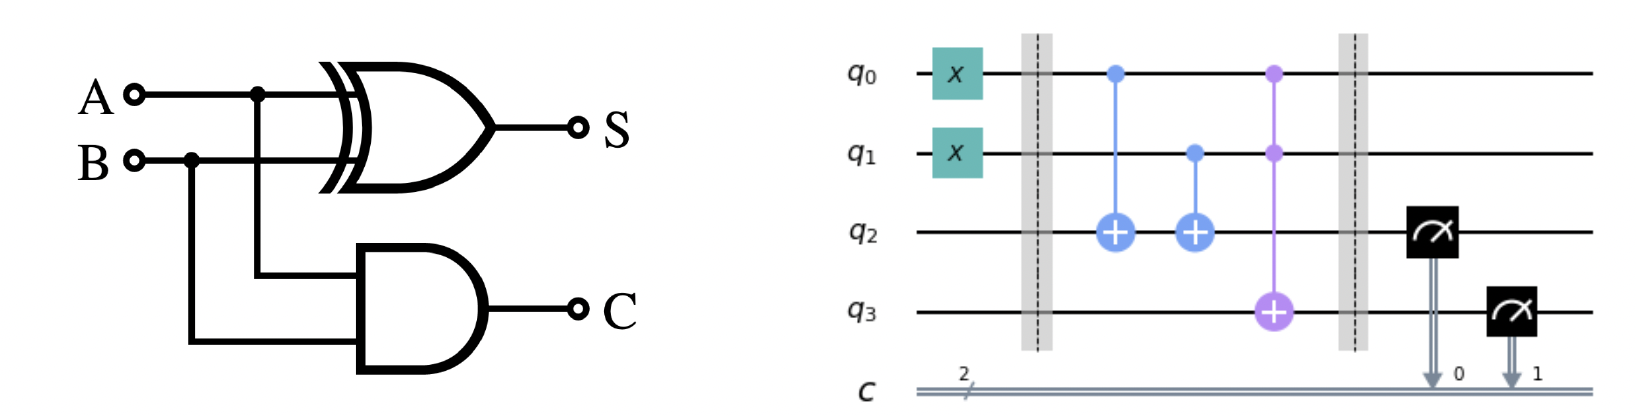

# 2. 単一量子ビット回路


## 2.1 量子状態とブロッホ球

量子ビットの状態は、$|0\rangle$ と $|1\rangle$ の重ね合わせの状態で表します。任意の量子ビットは以下のように表します。

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$ 

ここで $\alpha$ と $\beta$ は、 $|\alpha|^2+|\beta|^2=1$ を満たす複素数で、確率振幅と呼ばれます。

$|0\rangle$と$|1\rangle$は、
$|0\rangle = \begin{pmatrix}
1 \\
0
\end{pmatrix}$ 、
$|1\rangle = \begin{pmatrix}
0\\
1
\end{pmatrix}$
とかけるので、

$$|\psi\rangle = \alpha\begin{pmatrix}
1 \\
0
\end{pmatrix}+ \beta\begin{pmatrix}0\\
1
\end{pmatrix} = \begin{pmatrix}
\alpha \\
\beta
\end{pmatrix}$$

とも表すことができ、$|\psi\rangle =\begin{pmatrix}
\alpha \\
\beta
\end{pmatrix}$ は状態ベクトルとも呼びます。

(行列の計算についてはこちらを参照してください：https://github.com/quantum-tokyo/kawasaki-quantum-camp/blob/main/vector_matrix.pdf)

1量子ビットの状態は **ブロッホ球** を使うと理解しやすいです。このとき、$|\psi\rangle =\cos\frac{\theta}{2}|0\rangle+e^{i\varphi}\sin\frac{\theta}{2}|1\rangle= 
\left(
\begin{matrix}
\cos\frac{\theta}{2}\\
e^{i\varphi}\sin\frac{\theta}{2}
\end{matrix}
\right)
$ です。
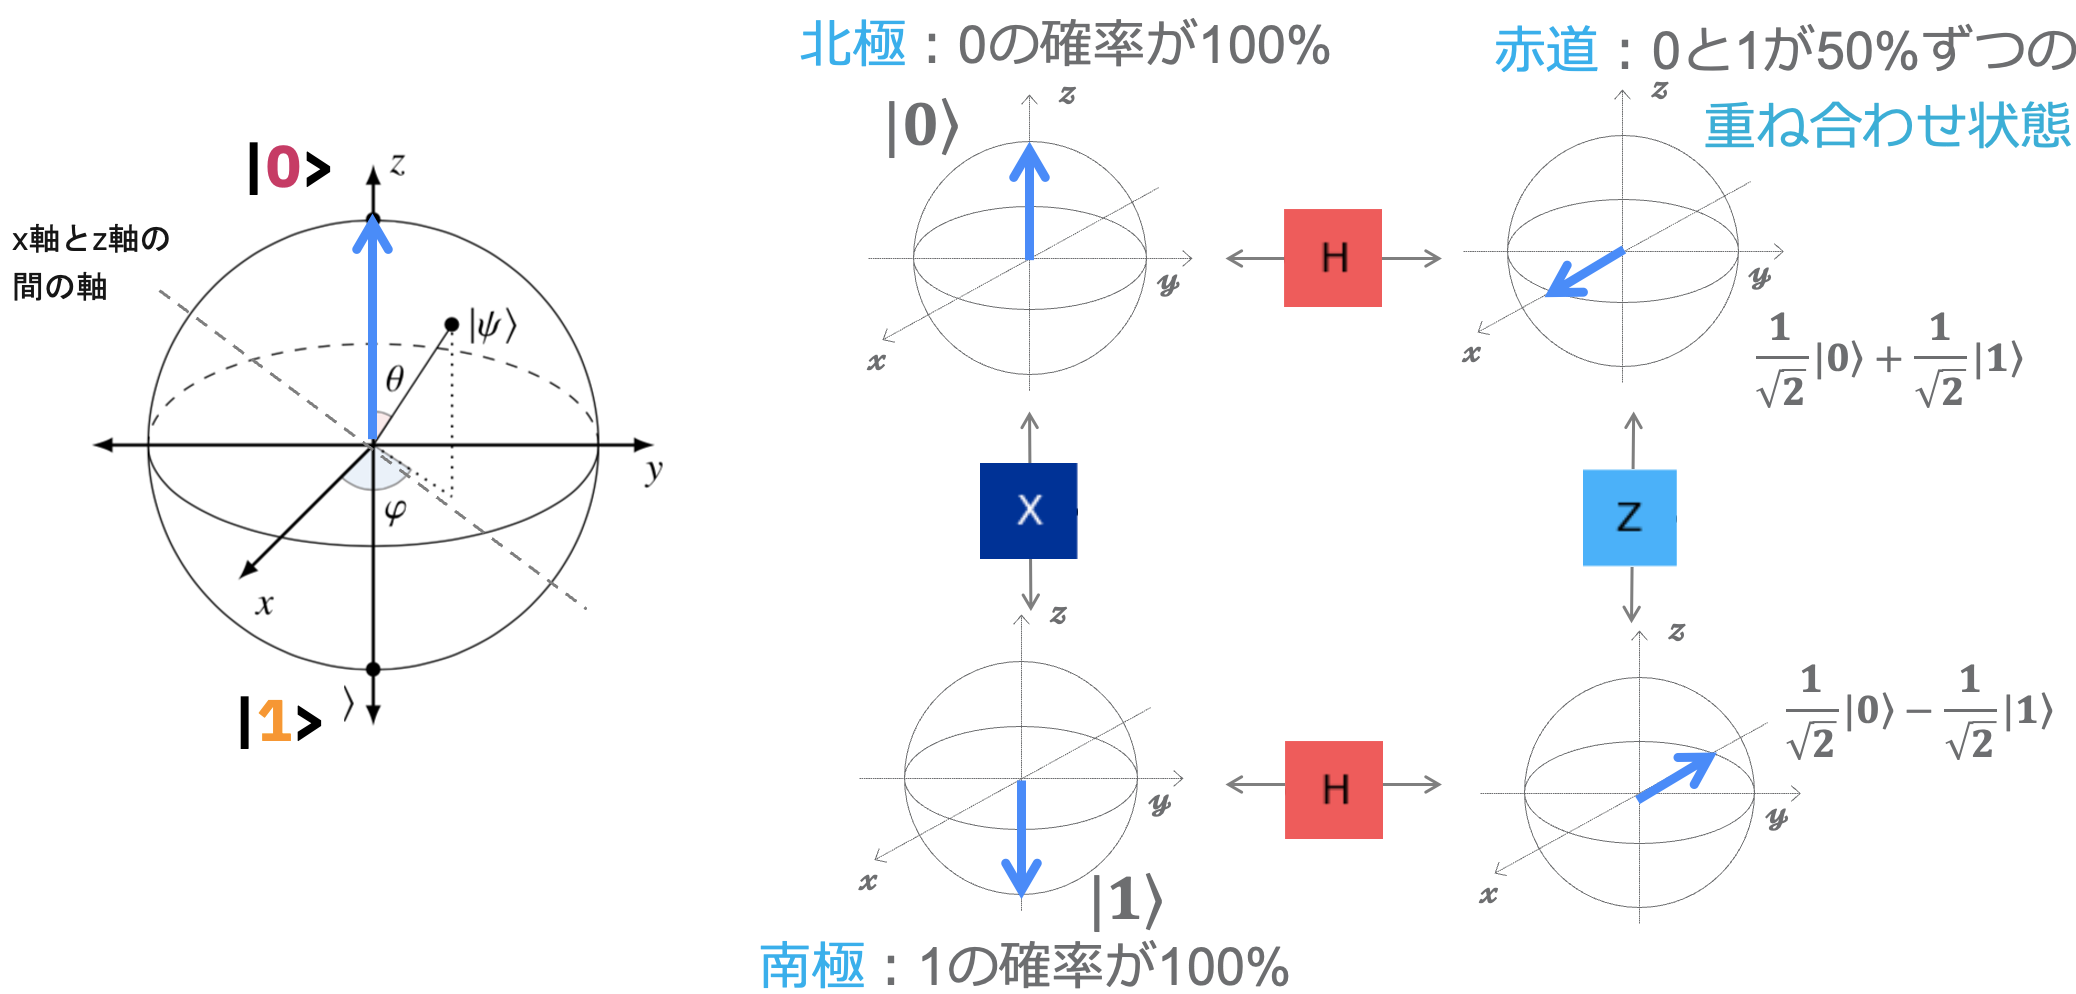

量子演算について、Qiskitで基本的な計算方法を学びます。     
コードセルは、セルを選択して「Shift」＋「Enter」で実行できます。

### 空の回路
1量子ビットの回路を作成し、描画します。

In [ ]:
from qiskit import QuantumCircuit
# １量子ビット回路を用意
qc = QuantumCircuit(1)

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# 状態ベクトルシミュレーターの実行
from qiskit.quantum_info import Statevector
sv = Statevector(qc)
print(sv)

# ブロッホ球の表示
from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(sv)

縦ベクトルが横ベクトル表示で、複素数(虚部の添字は j )で表示されています。</br>
IBM Quantumでは、初期状態は$|0\rangle$にセットされていますので、上記の量子回路の状態は、ベクトル表示で$ \begin{pmatrix}
1 \\
0
\end{pmatrix}$となっていて、ブロッホ球上でも$|0\rangle$になっていることがわかります。

### Xゲート
Xゲートはブロッホ球の$x$軸周りの$\pi$回転です。
$|0\rangle$にXゲートを適用すると$|1\rangle$、$|1\rangle$にXゲートを適用すると$|0\rangle$になるので、古典のNOTゲートのような操作が実現でき、ビット反転とも呼ばれます。

$X = \begin{pmatrix}
0 & 1 \\
1 & 0 \\
\end{pmatrix}$

In [ ]:
qc = QuantumCircuit(1)    # １量子ビット回路を用意

# Xゲートを0番目の量子ビットに操作します。
qc.x(0)

# 回路を描画
qc.draw(output="mpl")

上記の量子回路の状態は、行列ベクトル表示では

$X|0\rangle=  \begin{pmatrix}
0 & 1 \\\
1 & 0
\end{pmatrix} 
\begin{pmatrix}
1 \\\
0
\end{pmatrix} 
 =\begin{pmatrix}
0 \\\
1
\end{pmatrix} = |1\rangle$ 

となります。次にこの回路の出力ベクトルを状態ベクトルシミュレーターを使って実行してみます。

In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

# ブロッホ球の表示
plot_bloch_multivector(sv)

### Hゲート

Hadamardゲート(アダマールゲート)はブロッホ球の$x$軸と$z$軸の中間の軸周りの$\pi$回転です。
例えば$|0\rangle$にHゲートを適用すると、$\frac{|0\rangle + |1\rangle}{\sqrt{2}}$のような重ね合わせ状態を作ることができます。

$H = \frac{1}{\sqrt{2}}\begin{pmatrix}
1 & 1 \\
1 & -1 \\
\end{pmatrix}$

In [ ]:
qc = QuantumCircuit(1)    # １量子ビット回路を用意 

# Hゲートを0番目の量子ビットに操作します。
qc.h(0)

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

# ブロッホ球の表示
plot_bloch_multivector(sv)

これは、$H|0\rangle= \frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 1 \\\
1 & -1
\end{pmatrix} 
\begin{pmatrix}
1 \\\
0
\end{pmatrix} 
 =\frac{1}{\sqrt{2}}\begin{pmatrix}
1 \\\
1
\end{pmatrix} 
=\begin{pmatrix}
0.707\cdot\cdot\cdot \\\
0.707\cdot\cdot\cdot
\end{pmatrix} 
=\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)=|+\rangle$ です。




$H$ゲートを$|0\rangle$に実行すると、$|0\rangle$と$|1\rangle$の均等な重ね合わせ状態が作れることが分かります。この状態は$|+\rangle$とも呼ばれます。


### $|-\rangle$状態

In [ ]:
qc = QuantumCircuit(1)    # １量子ビット回路を用意 

# Xゲートを0番目の量子ビットに操作します。
qc.x(0)

# 次にHゲートを0番目の量子ビットに操作します。
qc.h(0)

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

# ブロッホ球の表示
plot_bloch_multivector(sv)

$H|1\rangle= \frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 1 \\\
1 & -1
\end{pmatrix} 
\begin{pmatrix}
0 \\\
1
\end{pmatrix} 
 =\frac{1}{\sqrt{2}}\begin{pmatrix}
1 \\\
-1
\end{pmatrix} 
=\begin{pmatrix}
0.707\cdot\cdot\cdot \\\
-0.707\cdot\cdot\cdot
\end{pmatrix} 
=\frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)=|-\rangle$


$|1\rangle$に$H$ゲートを実行した結果、$|0\rangle$と$|1\rangle$の均等な重ね合わせ状態になりますが、$|1\rangle$の符号がマイナスになります。この状態は$|-\rangle$とも呼ばれます。

## 2.2 その他の1量子ビットゲート

そのほかの代表的な1量子ビットゲートをこちらで確認してみましょう：https://javafxpert.github.io/grok-bloch/

## 演習1
次の量子回路をプログラミングし、状態ベクトルシミュレーターで実行して、ブロッホ球を表示してみましょう。

(1) $XX|0\rangle$

(2) $HH|0\rangle$  

(3) $ZH|1\rangle$

ヒント：Zゲートはブロッホ球の$z$軸周りの$\pi$回転です。位相反転とも呼ばれ、`qc.z(0)` のようにコーデイングします。

$Z = \begin{pmatrix}
1 & 0 \\
0 & -1 \\
\end{pmatrix}$


In [ ]:
### (1) XX|0> ###

# １量子ビット回路を用意 
qc = ##コードを記入します##

# Xゲートを0番目の量子ビットに操作します。
qc.##コードを記入します##

# もう一度、Xゲートを0番目の量子ビットに操作します。
qc.##コードを記入します##

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

# ブロッホ球の表示
plot_bloch_multivector(sv)

In [ ]:
### (2) HH|0> ###
##コードを記入します##




In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

# ブロッホ球の表示
plot_bloch_multivector(sv)

In [ ]:
### (3) ZH|1> ###
##コードを記入します##




In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

# ブロッホ球の表示
plot_bloch_multivector(sv)

## 2.3 測定

量子ビット $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$ は観測することによって、 $|0\rangle$または$|1\rangle$へ状態が変わります。一般的な計算基底で測定を行うと、$|0\rangle$を得る確率は、$|\alpha|^2$ であり、$|1\rangle$を得る確率は、$|\beta|^2$ です（ボルンの法則）。

例えば、$|\psi\rangle=\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ を測定すると、$\frac{1}{2}$の確率で$|0\rangle$が測定（$\frac{1}{2}$の確率で$|1\rangle$が測定）されます。

測定するためには量子回路に測定ゲートを追加します。

In [ ]:
qc = QuantumCircuit(1,1) # 1量子ビットと1古典ビットの回路を作成します。
qc.h(0)
qc.measure(0,0) # 測定ゲートを追加

qc.draw(output="mpl")

[Qiskit Primitive](https://quantum.cloud.ibm.com/docs/guides/primitives)のSamplerで量子回路の出力をサンプリングします。実際の量子コンピューターで計算する前に、シミュレーター版の [StatevectorSampler](https://quantum.cloud.ibm.com/docs/ja/guides/simulate-with-qiskit-sdk-primitives#use-the-reference-sampler) を使ってみましょう。
1024回実行した結果、それぞれの状態が測定された回数を表示し、その測定結果をヒストグラムで表示します。

In [ ]:
# シミュレーター版のSampler
from qiskit.primitives import StatevectorSampler
sampler_sim = StatevectorSampler()

In [ ]:
# シミュレーターで実験
job = sampler_sim.run([qc]) # デフォルトのshot数は1024です
result = job.result()

# 測定された回数を表示
counts = result[0].data.c.get_counts()
print(counts)

# ヒストグラムで測定された回数をプロット
from qiskit.visualization import plot_histogram
plot_histogram(counts)

ほぼ50％ずつの確率で0と1が測定されることが確認できました。

# 3. 複数量子ビット回路ともつれ状態

## 3.1 複数量子ビット回路

In [ ]:
# ２量子ビット回路を作成します。
qc = QuantumCircuit(2)

# Hゲートを0番目の量子ビットに操作します。
qc.h(0)

# Hゲートを1番目の量子ビットに操作します。
qc.h(1)

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

2量子ビットの状態は、1量子ビットの積（テンソル積）で表せます。(テンソル積の計算についてはこちらを参照してください：https://github.com/quantum-tokyo/kawasaki-quantum-camp/blob/main/vector_matrix.pdf)

$|\psi\rangle=|q0\rangle \otimes|q1\rangle = (a|0\rangle+b|1\rangle) \otimes (c|0\rangle+d|1\rangle) $

$= ac|0\rangle|0\rangle+ad|0\rangle|1\rangle+bc|1\rangle|0\rangle+bd|1\rangle|1\rangle$

$= ac|00\rangle+ad|01\rangle+bc|10\rangle+bd|11\rangle$

(ただし、$|ac|^2+ |ad|^2+ |bc|^2+ |bd|^2=1$ )


Qiskitの初期値は、$|00\rangle=|0\rangle\otimes|0\rangle$なので、$H$をそれぞれの量子ビットに操作させることで均等な重ね合わせの状態になります。

$H|0\rangle \otimes H|0\rangle=\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle) \otimes \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle) = \frac{1}{2}(|00\rangle+|01\rangle+|10\rangle+|11\rangle)$

$$ 
=\frac{1}{2}\left( \begin{pmatrix} 1 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 1 \\ 1 \end{pmatrix}\right) = \frac{1}{2}\begin{pmatrix} 1 \\ 1 \\ 1 \\ 1 \end{pmatrix}=\frac{1}{2}\left(\begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}+\begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix}+\begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix}+\begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}\right)
$$

測定のルールも1量子ビット状態の場合と同じで、例えば $|00\rangle$ を測定する確率は、$|ac|^2$です。

In [ ]:
# ブロッホ球の表示
plot_bloch_multivector(sv)

次に、この状態を測定してみましょう。

まず、測定回路を追加します。

In [ ]:
# ２量子ビットと2古典ビットの回路を作成します。
qc = QuantumCircuit(2,2)

# ゲートを適用します。
qc.h(0)
qc.h(1)

# 測定ゲートを追加
qc.measure(0, 0)
qc.measure(1, 1)

# 回路を描画
qc.draw(output="mpl")

次にシミュレーター版のSamplerで実行します。1024回実行した結果、それぞれの状態が測定された回数とヒストグラムを表示します。

In [ ]:
# シミュレーター版のSamplerで実行
job = sampler_sim.run([qc]) # defoult shot number is 1024
result = job.result()

#  測定された回数を表示
counts = result[0].data.c.get_counts()
print(counts)

# ヒストグラムで測定された回数をプロット
plot_histogram(counts)

$|00\rangle$、$|01\rangle$、$|10\rangle$、$|11\rangle$の状態がほぼ25%ずつ均等に測定されました。

## 3.2 複数量子ゲート

代表的な複数量子ゲートである $CNOT$ゲート（$CX$ゲート）は、2量子ビットにかかる量子ゲートで、制御ビットが1のときのみ、目標ビットの値を反転します。　　　　
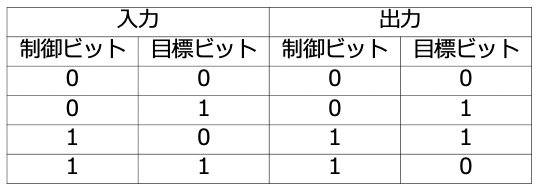

まず、q0とq1が両方とも0の場合を計算してみましょう。

In [ ]:
# ２量子ビット回路を作成します。 
qc = QuantumCircuit(2,2)

# q0, q1が0の場合
qc.cx(0,1)   # CNOTゲートの制御ビットをq0、目標ビットをq1にセットします。

# 回路を描画
qc.draw(output="mpl")

In [ ]:
## 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

$|00\rangle$ に$CX$ゲートを操作しても$|00\rangle$ のままです。

次に、$|01\rangle$ に$CX$ゲートを操作します。

ここで、Qiskitでは、最下位ビット(LSB)が右端で、多くの量子情報の教科書とは逆であることに注意してください。つまり、1量子ビット目が一番右のビットで、2量子ビット目が右から2番目のビットです。$|01\rangle$ とは、q0が1で、q1が0を表しています。


In [ ]:
qc = QuantumCircuit(2,2)

# q0=1, q1=0の場合
qc.x(0)    # q0を1にします。
qc.cx(0,1)   # CNOTゲートの制御ゲートをq0、目標ゲートをq1にセットします。

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# 状態ベクトルシミュレーターの実行
sv = Statevector(qc)
print(sv)

$|01\rangle$ に$CX$ゲートを操作すると$|11\rangle$ になりました。

シミュレーターで計算してみましょう。

In [ ]:
# 回路を測定
qc.measure(0, 0)
qc.measure(1, 1)

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# シミュレーター版のSamplerで実行
job = sampler_sim.run([qc]) # defoult shot number is 1024
result = job.result()

#  測定された回数を表示
counts = result[0].data.c.get_counts()
print(counts)

# ヒストグラムで測定された回数をプロット
plot_histogram(counts)

$|11\rangle$の状態が100%測定されます。


## 3.3 量子もつれと実デバイスでの実行

量子計算上でも重要な状態となる、量子もつれ状態（エンタングルメント状態）を生成してみましょう。

2量子ビットの量子もつれ状態の1つの例が次のような形になります。
$$\frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|11\rangle$$

これは、「片方の量子ビットが$|0\rangle$の場合に、もう片方の量子ビットも$|0\rangle$になっている」状態と、「片方の量子ビットが$|1\rangle$の場合に、もう片方の量子ビットも$|1\rangle$になっている」状態の重ね合わせ状態になっています。つまり、片方の量子ビットの状態が決まると、残りの量子ビットが確定するような状態となっています。別の言い方をすると、$|00\rangle$と$|11\rangle$という2つの状態が半々の確率で観測されることを示しています。

この状態は次のようにして作ることができます。まず片方の量子ビット($q_0$)に $H$ゲートをかけて重ね合わせの状態にします。

$$|00\rangle \to \frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|01\rangle$$

その後、CXゲートを作用させます。$q_0$をコントロールビット、$q_1$をターゲットビットとします。すると、右側が1の量子ビットに対して、残った方の量子ビットが反転します。

$$\frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|01\rangle \to \frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|11\rangle$$

では、演習2で実際にこの量子状態を作ってみましょう。<br>


## 演習2

(1) 次の回路をプログラミングし、Aerシミュレーターを実行して、結果をヒストグラムで表示してください。$|00\rangle$と$|11\rangle$がほぼ半分ずつになることを確認します。
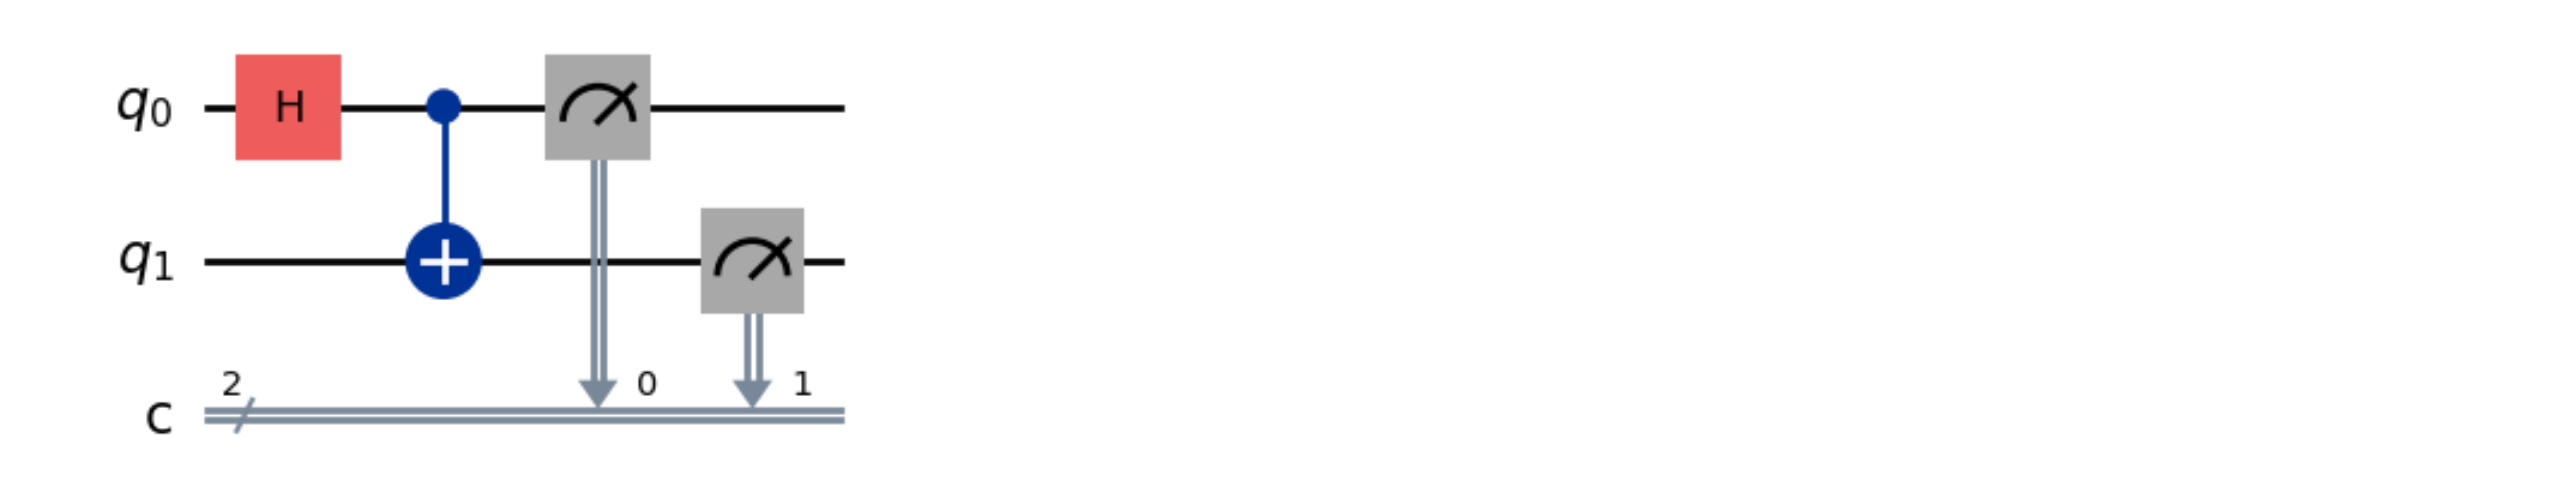

In [ ]:
# 2量子ビット回路の用意
qc = ##コードを記入します##

# 2量子ビットのエンタングルメント回路の作成
qc.##コードを記入します##
qc.##コードを記入します##

# 回路を測定
qc.##コードを記入します##
qc.##コードを記入します## 

# 回路を描画
qc.draw(output="mpl")

In [ ]:
# シミュレーター版のSamplerで実行
job = sampler_sim.run([qc]) # defoult shot number is 1024
result = job.result()

#  測定された回数を表示
counts = result[0].data.c.get_counts()
print(counts)

# ヒストグラムで測定された回数をプロット
plot_histogram(counts)

(2) 以下のコードを実行して実デバイスで実行してみましょう。

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name = "nedo_q") 
service.backends()

In [ ]:
# 以下でデバイスを指定できます。
backend = service.backend('ibm_fez')

In [ ]:
#一番空いているバックエンドを自動的に選択することもできます
backend = service.least_busy(operational=True)
print("最も空いているバックエンドは: ", backend)

バックエンド・デバイスによって、ネイティブ・ゲート（実行できるゲート）がきまっています。また、デバイスによって、カップリングマップが異なる場合もあります。各デバイスの情報については、こちらから確認できます：https://quantum.cloud.ibm.com/computers

回路をトランスパイルすることで、実際のバックエンドでの実行に最適化された回路を作成します。トランスパイルの詳細については、こちらのドキュメントをご覧ください：https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler

In [ ]:
# 回路を実機で実行可能なゲートにトランスパイルします
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)
isa_circuit.draw("mpl", idle_wires=False)

回路がトランスパイルされ、バックエンド・デバイスのネイティブ・ゲートを使った回路に変換されました。これで実デバイスで回路を実行できます。(Sampler の高度なコーディング手法については、今後更新が入る予定です：https://quantum.cloud.ibm.com/docs/en/guides/migrate-to-client-side-primitives )

In [ ]:
# Samplerで実行します
from qiskit_ibm_runtime.executor_sampler import Sampler
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit]) # default shot number is 4096

print("job id:", job.job_id()) # job idの確認

In [ ]:
# ジョブの実行状態を確認します
job.status()

In [ ]:
# 待ち時間が長い時に後から結果を確認する場合
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name = "nedo_q")
job = service.job('d8ig44lv8cos73f5i8q0') # 例です。上に出力された自分のjob_idを入れて実行してください。
job.status()

上記のセルの実行の結果、'DONE' が表示されたら、実機での実行が終わっているので、以下のセルを実行して結果を確認します。

In [ ]:
### 'DONE'になってから実行します ###
result = job.result()
counts = result[0].data.c.get_counts()
print(counts)

In [ ]:
# ヒストグラムで測定された回数をプロット
plot_histogram(counts)

## 3.4 GHZ状態

3量子ビット以上が完全にエンタングルした状態をGHZ状態 (Greenberger–Horne–Zeilinger state) と呼びます。

$$\frac{1}{\sqrt 2}(|000\rangle + |111\rangle)$$

３量子ビットのGHZ状態は、次のような量子回路で作成することができます。

In [ ]:
qc = QuantumCircuit(3)

qc.h(0)
qc.cx(0,1)
qc.cx(1,2)

qc.measure_all()

qc.draw("mpl")

量子回路の「深さ」は、量子回路を互いに同時に実行可能なゲートの層に分割したときのその層の最小の数のことで、量子回路を評価する指標としてよく使われます。

以下で、量子回路の深さを調べることができ、上の回路の深さは4です。

In [ ]:
qc.depth()

例えば、以下の回路の深さは測定ゲートを含めて、左から、4, 3, 3 です。

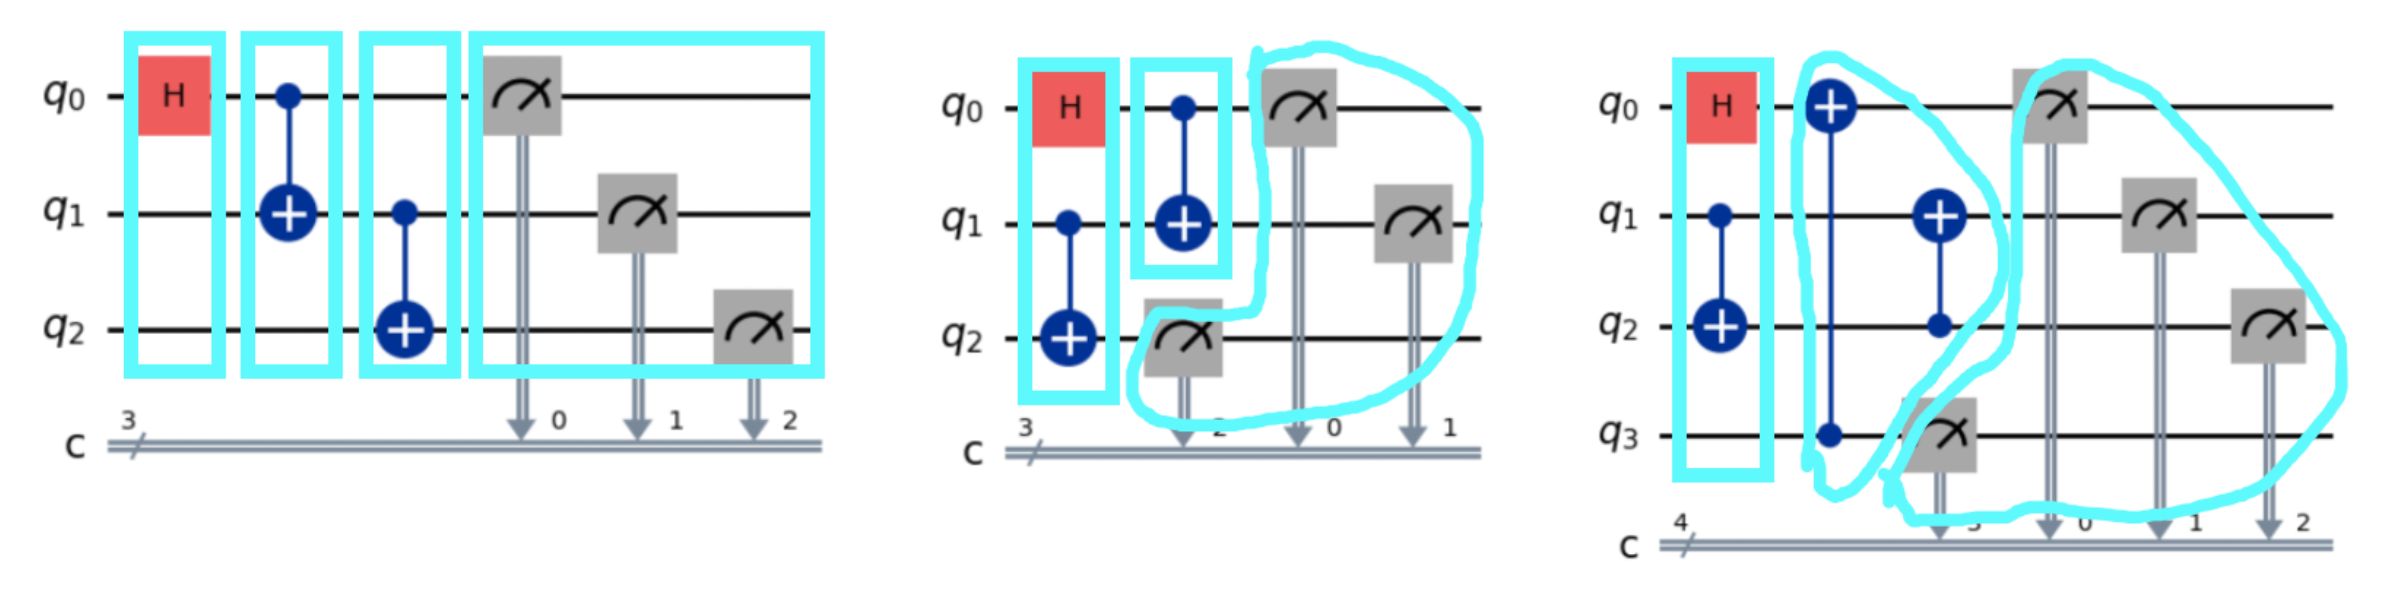

## 演習 3

$8$ 量子ビットのGHZ状態は、以下のようになります。

$$\frac{1}{\sqrt 2}(|00000000\rangle + |11111111\rangle)$$

この状態を最も浅い回路で作ってみましょう。最も浅い量子回路の depth は、測定ゲートを合わせて 5 です！

In [ ]:
qc = QuantumCircuit(8,8)

# ここから下にコードを書きます






# ここから上にコードを書きます

# 測定
for i in range(8):
    qc.measure(i, i)

qc.draw("mpl")
#print(qc.depth())

In [ ]:
print(qc.depth())

In [ ]:
# シミュレーター版のSamplerで実行
job = sampler_sim.run([qc]) # defoult shot number is 1024
result = job.result()

#  測定された回数を表示
counts = result[0].data.c.get_counts()
print(counts)

# ヒストグラムで測定された回数をプロット
plot_histogram(counts)

### 応用編：実機の量子コンピューターでGHZ状態を作る場合

実際の量子コンピューターでGHZ回路を作成する場合には、量子ビットの接続制限のため、また別の工夫が必要になります。実機の量子コンピューターを使って、精度の良いGHZ状態を作る工夫については、こちらを参照ください：https://quantum-tokyo.github.io/introduction/courses/utility-scale-quantum-computing/utility-iii-ja.html

© IBM Corp., 2026